In [3]:

import xarray as xr
import pandas as pd


ds_sat = xr.open_dataset('LGMR_data/ds_sat_flipped.nc')
# ds_sat.info()

df_pre = pd.read_csv(r"D:\VScode\Inso_LGMR\inso_data\pre.csv")



=== Subset length = 60 ===
Using libSizes = 10 20 30


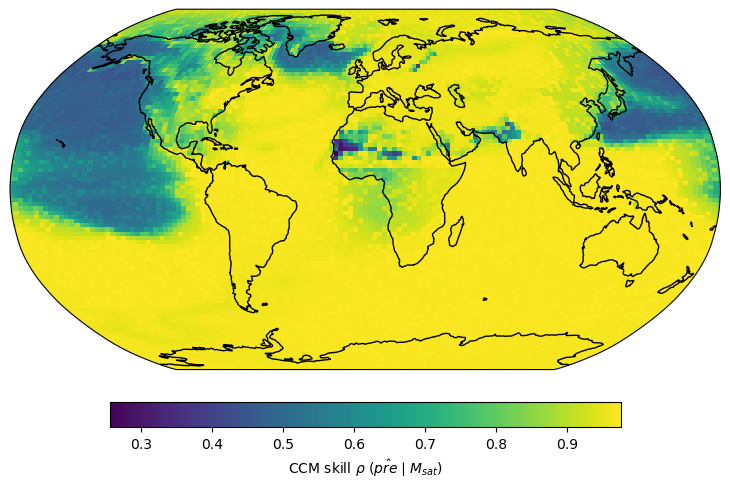


=== Subset length = 70 ===
Using libSizes = 10 20 30 40


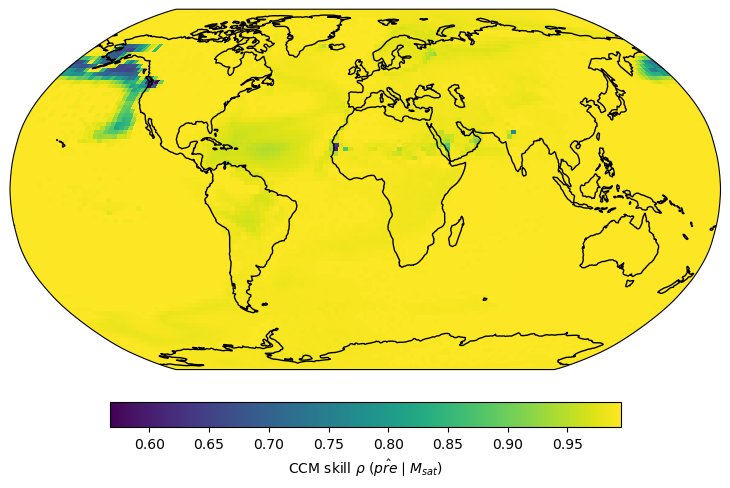


=== Subset length = 80 ===
Using libSizes = 10 20 30 40 50


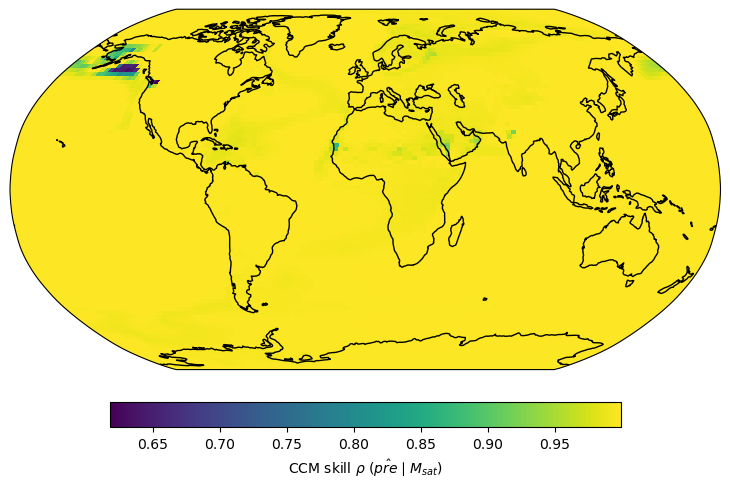


=== Subset length = 90 ===
Using libSizes = 10 20 30 40 50 60


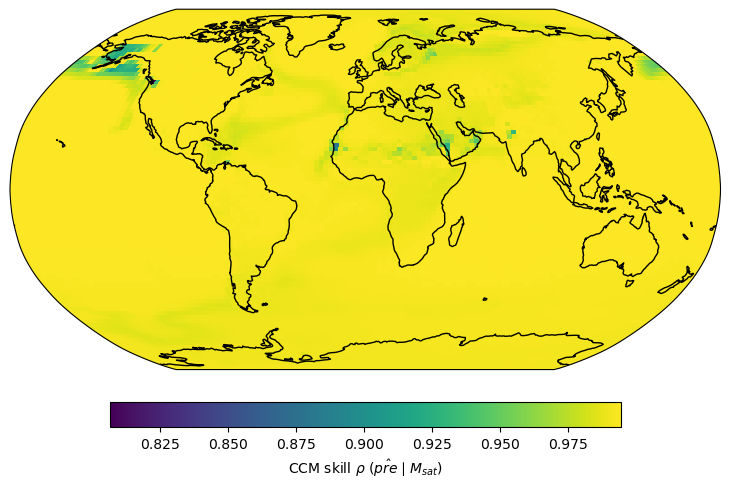


=== Subset length = 100 ===
Using libSizes = 10 20 30 40 50 60 70


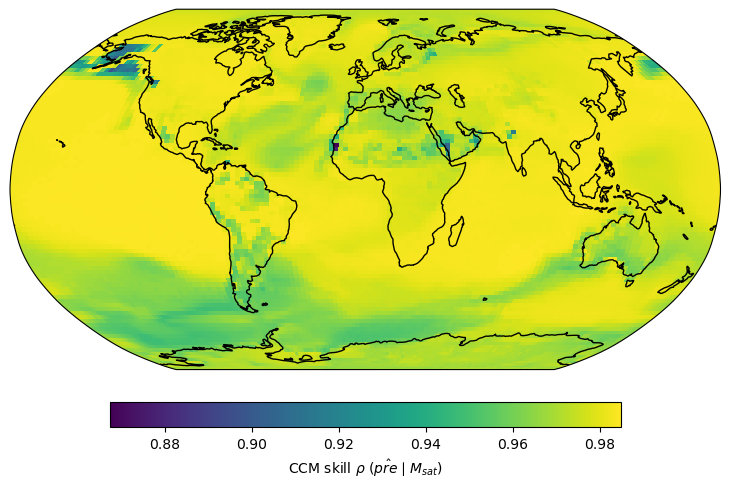


=== Subset length = 110 ===
Using libSizes = 10 20 30 40 50 60 70 80


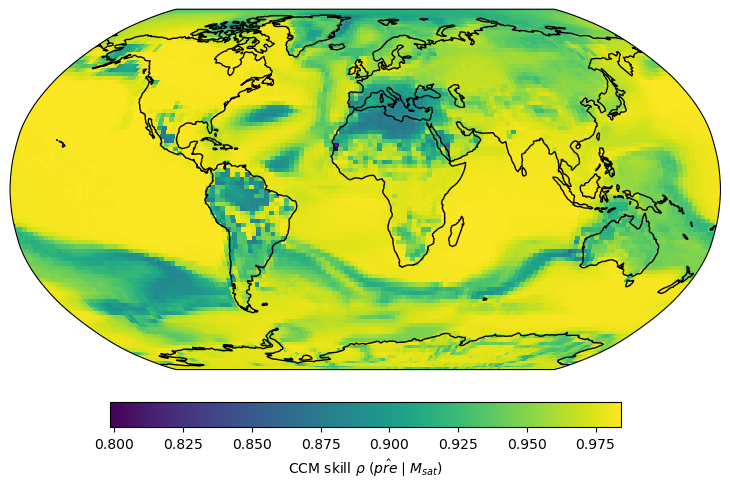


=== Subset length = 120 ===
Using libSizes = 10 20 30 40 50 60 70 80 90


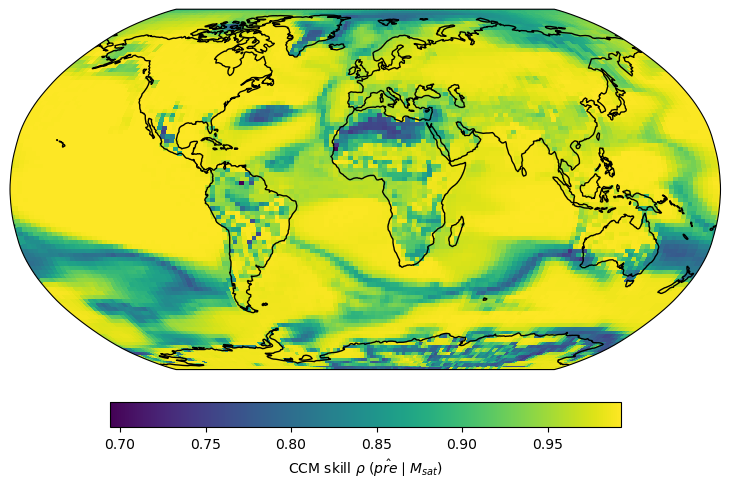

In [6]:
import numpy as np
from toolbox import ccm_map
import importlib
importlib.reload(ccm_map)

for subset_length in range(60, 121, 10):

    ds_sat_subset = ds_sat.isel(age=slice(0, subset_length))

    df_pre_subset = df_pre.iloc[:subset_length].copy()

    max_lib = subset_length - 30
    # If max_lib < 10, we skip
    if max_lib < 10:
        print(f"Subset length {subset_length} too small for library sizes.")
        continue
    libs = list(range(10, max_lib + 1, 10))
    # Convert to the space-separated string required by pyEDM
    libSizes_str = " ".join(str(L) for L in libs)

    print(f"\n=== Subset length = {subset_length} ===")
    print(f"Using libSizes = {libSizes_str}")

    # 4) Now call cal_raw_ccm_map on these subsets
    rho_map = ccm_map.cal_raw_ccm_map(
        ds_sat      = ds_sat_subset,
        df_pre      = df_pre_subset,
        E           = 3,     # example
        tau         = 5,     # example
        Tp          = 0,     # example
        libSizes    = libSizes_str,
        v_rage      = 'auto',
        show_plot   = True,  # set to False if you don't want a figure each time
        dpi         = 100
    )


=== Sliding window from 0 to 70 (length=70) ===
libSizes = 10 20 30 40


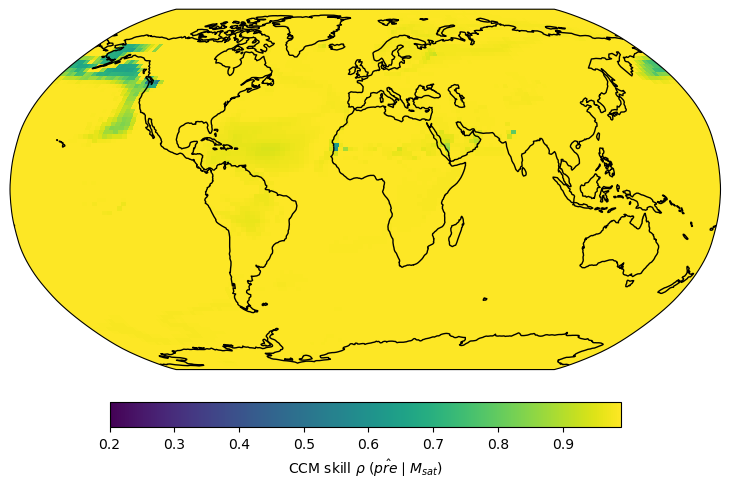


=== Sliding window from 10 to 80 (length=70) ===
libSizes = 10 20 30 40


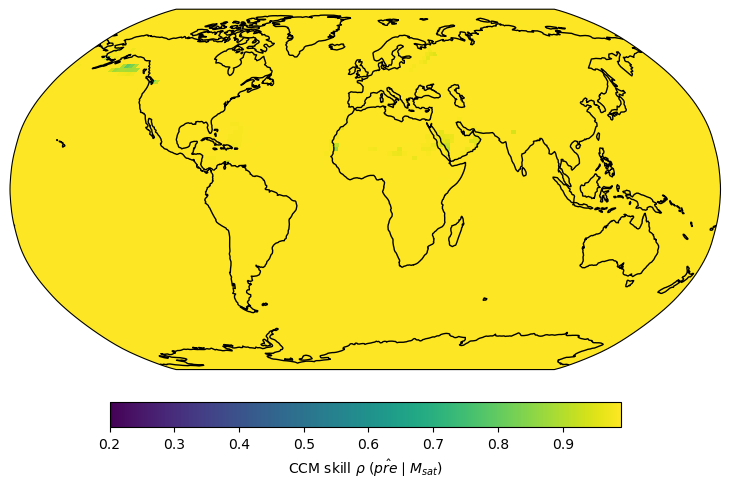


=== Sliding window from 20 to 90 (length=70) ===
libSizes = 10 20 30 40


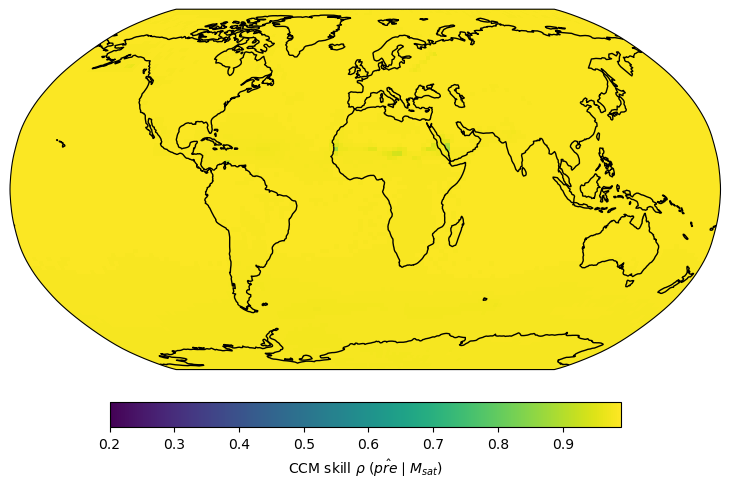


=== Sliding window from 30 to 100 (length=70) ===
libSizes = 10 20 30 40


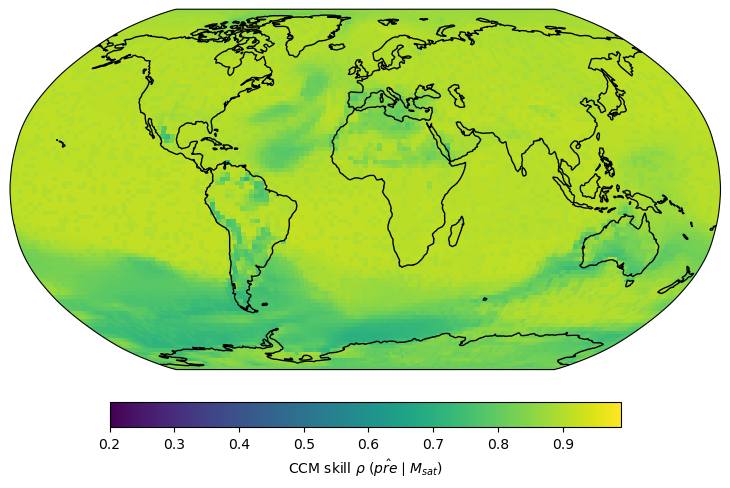


=== Sliding window from 40 to 110 (length=70) ===
libSizes = 10 20 30 40


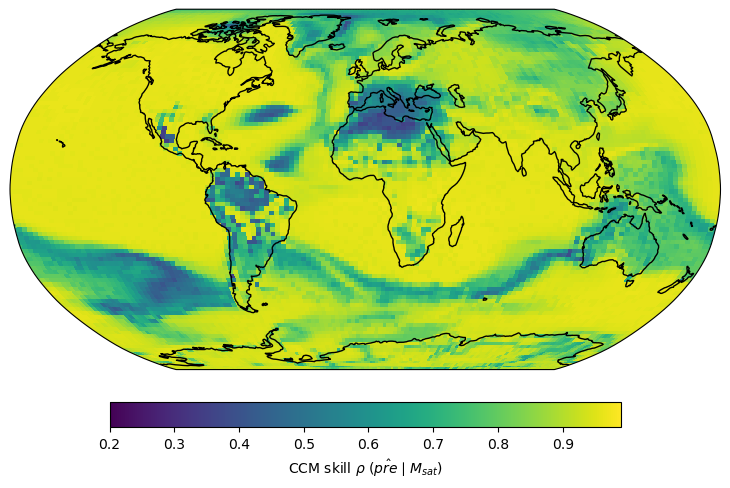


=== Sliding window from 50 to 120 (length=70) ===
libSizes = 10 20 30 40


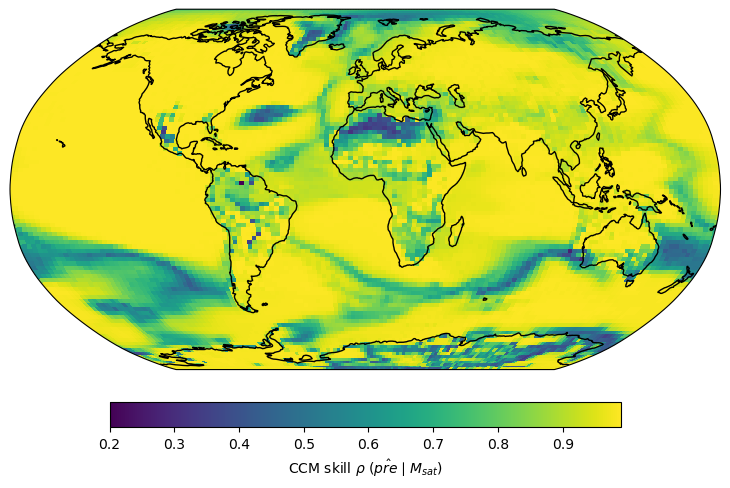

In [10]:
import numpy as np
from toolbox import ccm_map
import importlib
importlib.reload(ccm_map)

# Total length of the time dimension
nTime = ds_sat.sizes["age"]
window_len = 70
slide_step = 10

# For each starting index, create a window of length 70
# Slide by 10 until reaching the end of the time series.
for start_idx in range(0, nTime - window_len + 1, slide_step):
    end_idx = start_idx + window_len  # exclusive slice boundary

    ds_sat_subset = ds_sat.isel(age=slice(start_idx, end_idx))
    df_pre_subset = df_pre.iloc[start_idx:end_idx].copy()

    # We'll fix the library sizes to 10, 20, 30, 40 as requested
    libSizes_str = "10 20 30 40"

    print(f"\n=== Sliding window from {start_idx} to {end_idx} (length={window_len}) ===")
    print(f"libSizes = {libSizes_str}")

    # Call cal_raw_ccm_map on these subsets
    rho_map = ccm_map.cal_raw_ccm_map(
        ds_sat    = ds_sat_subset,
        df_pre    = df_pre_subset,
        E         = 3,        # Example
        tau       = 5,        # Example
        Tp        = 0,        # Example
        libSizes  = libSizes_str,
        show_plot = True,      # Set to False if you want to suppress plots
        dpi       = 100,
        v_range=[0.2,0.99]
    )



=== Sliding window from 0 to 70 (length=70) ===
libSizes = 49


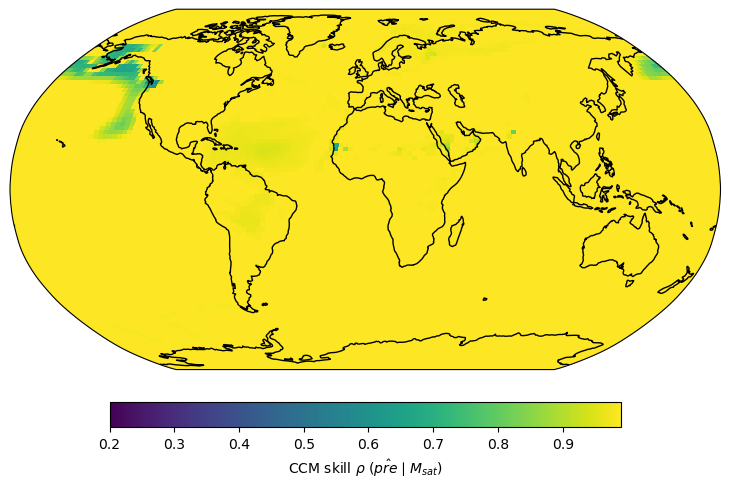


=== Sliding window from 10 to 80 (length=70) ===
libSizes = 49


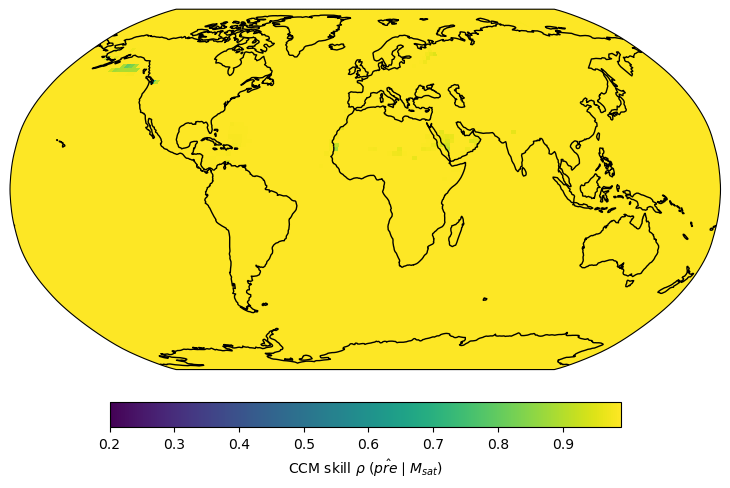


=== Sliding window from 20 to 90 (length=70) ===
libSizes = 49


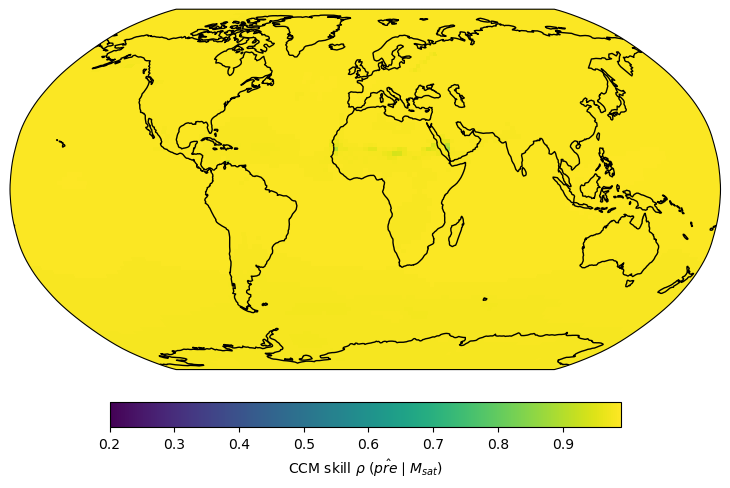


=== Sliding window from 30 to 100 (length=70) ===
libSizes = 49


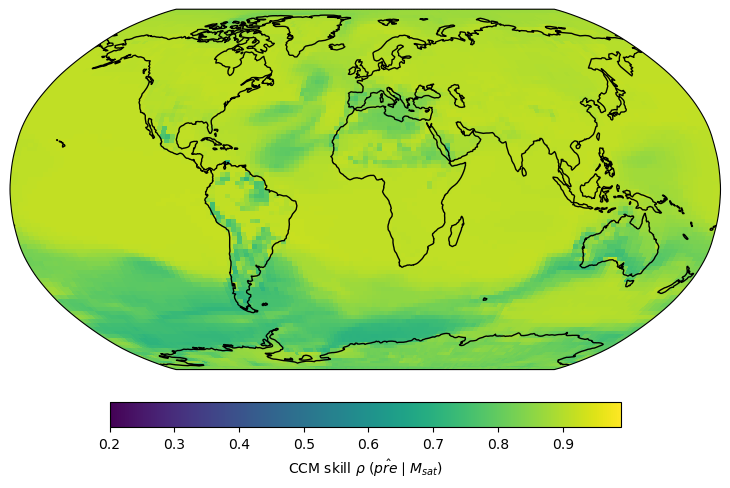


=== Sliding window from 40 to 110 (length=70) ===
libSizes = 49


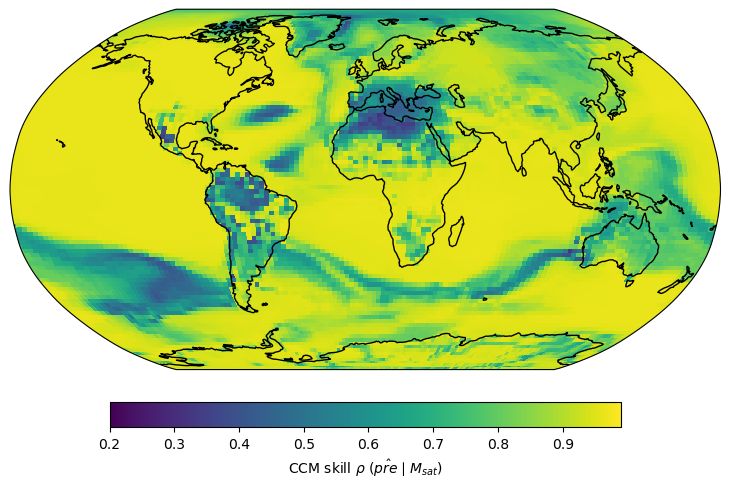


=== Sliding window from 50 to 120 (length=70) ===
libSizes = 49


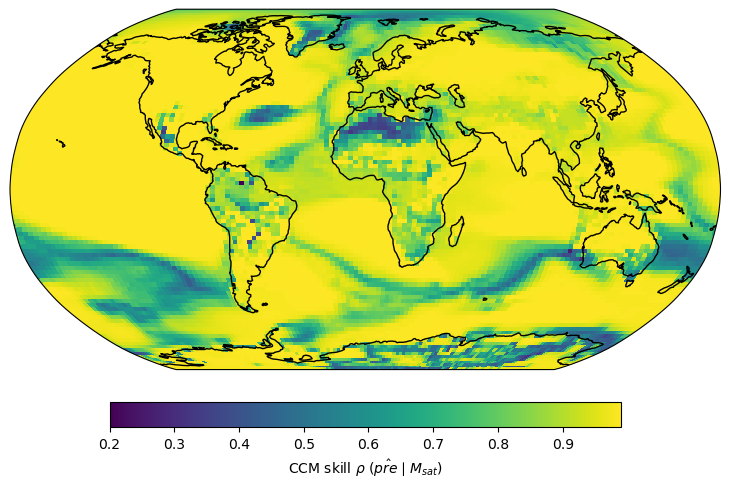

In [17]:
import numpy as np
from toolbox import ccm_map
import importlib
importlib.reload(ccm_map)

# Total length of the time dimension
nTime = ds_sat.sizes["age"]
window_len = 70
slide_step = 10

# For each starting index, create a window of length 70
# Slide by 10 until reaching the end of the time series.
for start_idx in range(0, nTime - window_len + 1, slide_step):
    end_idx = start_idx + window_len  # exclusive slice boundary

    ds_sat_subset = ds_sat.isel(age=slice(start_idx, end_idx))
    df_pre_subset = df_pre.iloc[start_idx:end_idx].copy()

    # We'll fix the library sizes to 10, 20, 30, 40 as requested
    libSizes_str = "49"

    print(f"\n=== Sliding window from {start_idx} to {end_idx} (length={window_len}) ===")
    print(f"libSizes = {libSizes_str}")

    # Call cal_raw_ccm_map on these subsets
    rho_map = ccm_map.cal_raw_ccm_map(
        ds_sat    = ds_sat_subset,
        df_pre    = df_pre_subset,
        E         = 3,        # Example
        tau       = 5,        # Example
        Tp        = 0,        # Example
        libSizes  = libSizes_str,
        sample = 40,
        show_plot = True,      # Set to False if you want to suppress plots
        dpi       = 100,
        v_range=[0.2,0.99]
    )



=== Sliding window from 0 to 70 (length=70) ===
libSizes = 46


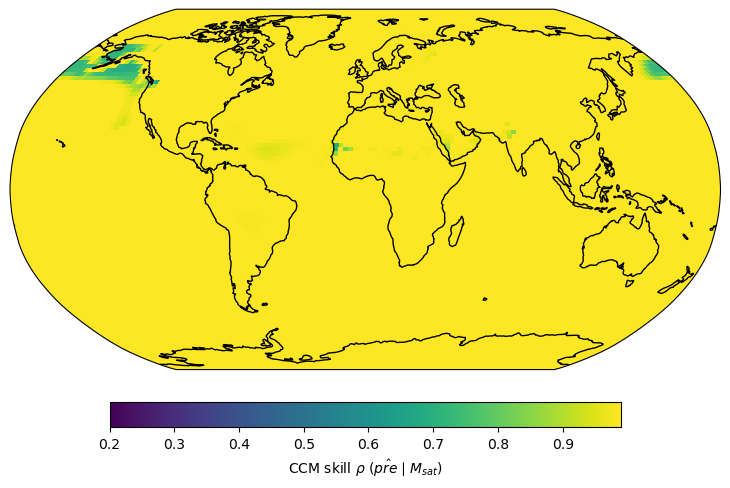


=== Sliding window from 10 to 80 (length=70) ===
libSizes = 46


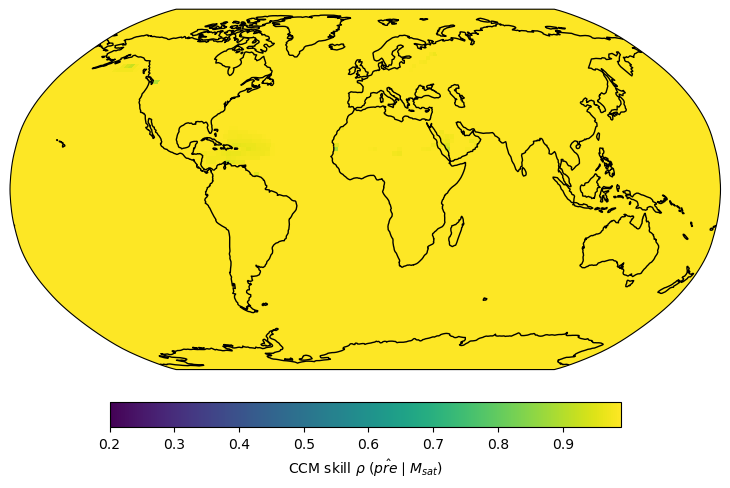


=== Sliding window from 20 to 90 (length=70) ===
libSizes = 46


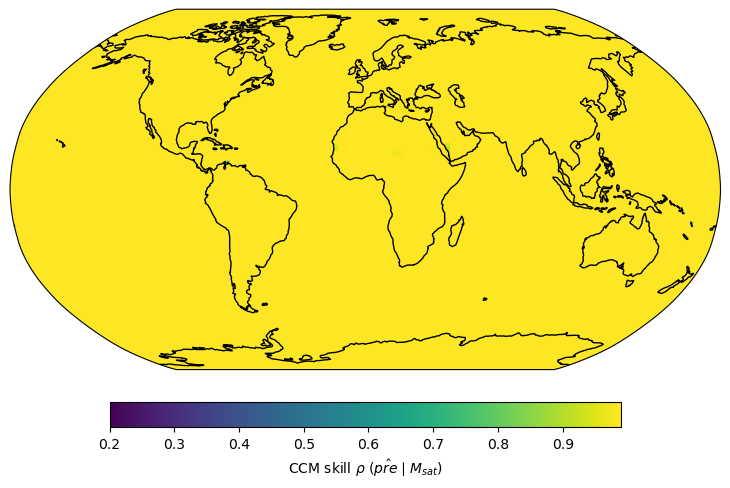


=== Sliding window from 30 to 100 (length=70) ===
libSizes = 46


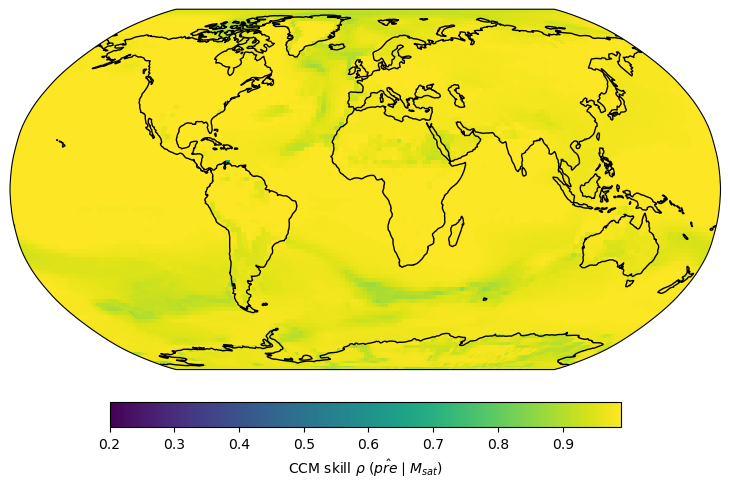


=== Sliding window from 40 to 110 (length=70) ===
libSizes = 46


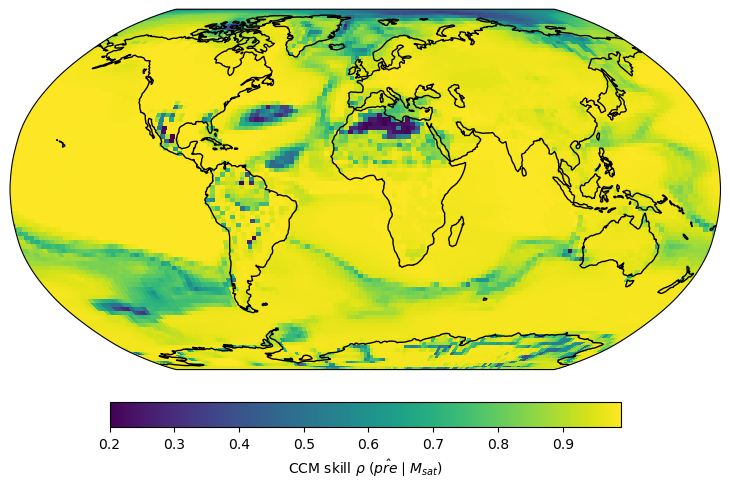


=== Sliding window from 50 to 120 (length=70) ===
libSizes = 46


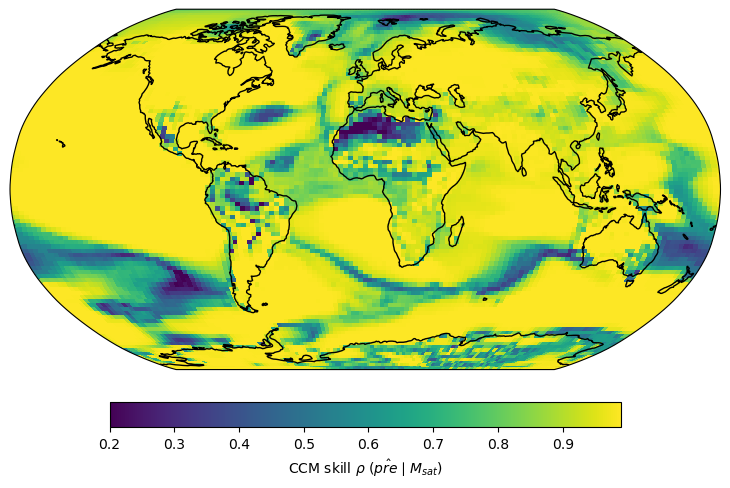

In [19]:
import numpy as np
from toolbox import ccm_map
import importlib
importlib.reload(ccm_map)

# Total length of the time dimension
nTime = ds_sat.sizes["age"]
window_len = 70
slide_step = 10

# For each starting index, create a window of length 70
# Slide by 10 until reaching the end of the time series.
for start_idx in range(0, nTime - window_len + 1, slide_step):
    end_idx = start_idx + window_len  # exclusive slice boundary

    ds_sat_subset = ds_sat.isel(age=slice(start_idx, end_idx))
    df_pre_subset = df_pre.iloc[start_idx:end_idx].copy()

    # We'll fix the library sizes to 10, 20, 30, 40 as requested
    libSizes_str = "46"

    print(f"\n=== Sliding window from {start_idx} to {end_idx} (length={window_len}) ===")
    print(f"libSizes = {libSizes_str}")

    # Call cal_raw_ccm_map on these subsets
    rho_map = ccm_map.cal_raw_ccm_map(
        ds_sat    = ds_sat_subset,
        df_pre    = df_pre_subset,
        E         = 3,        # Example
        tau       = 5,        # Example
        Tp        = -4,        # Example
        libSizes  = libSizes_str,
        sample = 40,
        show_plot = True,      # Set to False if you want to suppress plots
        dpi       = 100,
        v_range=[0.2,0.99]
    )